In [ ]:
import os
import pandas as pd
import kagglehub
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# Downloading both datasets to your session using kagglehub
print("Downloading Face-Age-Gender Dataset...")
face_age_gender_path = kagglehub.dataset_download("aadyasingh55/face-age-gender-dataset")

print("Downloading UTKFace Dataset...")
utkface_path = kagglehub.dataset_download("jangedoo/utkface-new")

print(f"\nFace-Age-Gender path: {face_age_gender_path}")
print(f"UTKFace path: {utkface_path}")


Face-Age-Gender path: /kaggle/input/datasets/aadyasingh55/face-age-gender-dataset
UTKFace path: /kaggle/input/datasets/jangedoo/utkface-new


In [2]:
image_paths = []
gender_labels = []

In [3]:
# Look inside the subfolder to find train.csv
face_dataset_folder = os.path.join(face_age_gender_path, "face_dataset")
csv_path = os.path.join(face_dataset_folder, "train.csv")

# Load the CSV file
df_train = pd.read_csv(csv_path)

# Extract paths and labels
for idx, row in df_train.iterrows():
    # Build the path: face_age_gender_path + face_dataset + train/test + filename
    img_path = os.path.join(face_dataset_folder, row['full_path'])
    if os.path.exists(img_path):
        image_paths.append(img_path)
        gender_labels.append(int(row['gender']))

print(f"Successfully loaded {len(image_paths)} images from the Face-Age-Gender dataset!")

Successfully loaded 34708 images from the Face-Age-Gender dataset!


In [4]:
# Direct path to the image folder
utk_folder = os.path.join(utkface_path, "UTKFace")

# Loop directly through the files in that folder
for file in os.listdir(utk_folder):
    if file.endswith(('.jpg', '.jpeg', '.png')) and '_' in file:
        parts = file.split('_')
        if len(parts) >= 2:
            utk_gender = parts[1] # '0' or '1'
            
            if utk_gender in ['0', '1']:
                # Align labels: UTK Face 0 (male) -> 1, UTK Face 1 (female) -> 0
                aligned_gender = 1 if utk_gender == '0' else 0
                
                image_paths.append(os.path.join(utk_folder, file))
                gender_labels.append(aligned_gender)

print(f"Done! Combined total across both datasets: {len(image_paths)} images.")

Done! Combined total across both datasets: 58416 images.


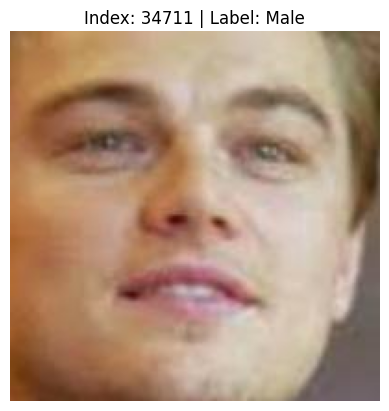

In [5]:
import matplotlib.pyplot as plt

def show_image(index):
    # Get the file path and label from our lists
    path = image_paths[index]
    label = gender_labels[index]
    
    # Open and display the image
    img = Image.open(path)
    plt.imshow(img)
    plt.axis('off')  # Hide the pixel grid lines
    
    # Set the title based on the aligned label
    gender_text = "Male" if label == 1 else "Female"
    plt.title(f"Index: {index} | Label: {gender_text}")
    plt.show()

# Test it by viewing the first image from UTKFace we looked at earlier!
show_image(34711)

In [6]:
image_paths[34709:34714]

['/kaggle/input/datasets/jangedoo/utkface-new/UTKFace/22_1_1_20170112233644761.jpg.chip.jpg',
 '/kaggle/input/datasets/jangedoo/utkface-new/UTKFace/21_1_3_20170105003215901.jpg.chip.jpg',
 '/kaggle/input/datasets/jangedoo/utkface-new/UTKFace/28_0_0_20170117180555824.jpg.chip.jpg',
 '/kaggle/input/datasets/jangedoo/utkface-new/UTKFace/17_1_4_20170103222931966.jpg.chip.jpg',
 '/kaggle/input/datasets/jangedoo/utkface-new/UTKFace/44_0_3_20170119201022260.jpg.chip.jpg']

In [7]:
gender_labels[34709:34714]

[0, 0, 1, 0, 1]

In [8]:
# Optimized PyTorch Dataset Class
class AdvancedGenderDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        try:
            img_path = self.paths[idx]
            image = Image.open(img_path).convert("RGB")
            label = self.labels[idx]
            
            if self.transform:
                image = self.transform(image)
                
            return image, torch.tensor(label, dtype=torch.long)
        except Exception as e:
            # Safeguard against any single corrupted image file in 58k photos
            return torch.zeros((3, 224, 224)), torch.tensor(0, dtype=torch.long)

In [9]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)), # Higher resolution for fine-grained details
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # ImageNet standards
])

In [13]:
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [12]:
from sklearn.model_selection import train_test_split

# 1. Split our combined 58k images into 80% train and 20% validation
train_paths, val_paths, train_labels, val_labels = train_test_split(
    image_paths, 
    gender_labels, 
    test_size=0.2, 
    random_state=42, 
    stratify=gender_labels  # Keeps the male/female ratio perfectly balanced
)

print(f"Training paths created: {len(train_paths)}")
print(f"Validation paths created: {len(val_paths)}")

# 2. Now initialize the datasets using the newly created paths
train_dataset = AdvancedGenderDataset(train_paths, train_labels, transform=train_transform)
val_dataset = AdvancedGenderDataset(val_paths, val_labels, transform=val_transform)

print("Datasets successfully initialized without errors!")

Training paths created: 46732
Validation paths created: 11684
Datasets successfully initialized without errors!


In [14]:
train_dataset = AdvancedGenderDataset(train_paths, train_labels, transform=train_transform)
val_dataset = AdvancedGenderDataset(val_paths, val_labels, transform=val_transform)

# Image Pre-Processing and Transformation

# Wrapping them on PyTroch DataLoaders

In [15]:
# Create high-throughput DataLoaders for the T4 GPU
# batch_size=64 optimizes T4 memory utilization for 224x224 images
# pin_memory=True speeds up data transfer from CPU RAM to GPU VRAM
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

print(f"Data pipeline complete!")
print(f"Total Training Batches: {len(train_loader)}")
print(f"Total Validation Batches: {len(val_loader)}")

# Sanity check: Grab one batch to make sure shapes look correct
images, labels = next(iter(train_loader))
print(f"\nSanity Check Batch Shapes:")
print(f"Images batch shape: {images.shape}") # Expecting [64, 3, 224, 224]
print(f"Labels batch shape: {labels.shape}") # Expecting [64]

Data pipeline complete!
Total Training Batches: 731
Total Validation Batches: 183

Sanity Check Batch Shapes:
Images batch shape: torch.Size([64, 3, 224, 224])
Labels batch shape: torch.Size([64])


# Loading Models

In [16]:
import torch.nn as nn
from torchvision import models

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [18]:
# This pulls the weights optimized on millions of general images
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 201MB/s]


In [19]:
# Customizing the classifier head for your Gender task
# EfficientNet-B0 has an output features dimension of 1280 before the final layer
num_ftrs = model.classifier[1].in_features

In [20]:
model.classifier[1] = nn.Sequential(
    nn.Dropout(p=0.4, inplace=True), # 40% dropout
    nn.Linear(num_ftrs, 2) # Output 2 dimensions: [Female score, Male score]
)

# Loss function and Optimizer

In [21]:
import torch.optim as optim

In [22]:
# Defining the Loss Function (Measures classification error)
criterion = nn.CrossEntropyLoss()

In [23]:
# Defining the Optimizer (AdamW automatically adjusts learning speed per weight)
# lr=1e-4 (0.0001) is a gentle starting point for stable transfer learning
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)

In [24]:
# Add a Learning Rate Scheduler (Slows down learning as accuracy peaks)
# This reduces the learning rate by half if validation loss stops improving for 2 epochs
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)

# Writing and executing training loop

In [ ]:
import time


num_epochs = 30
patience = 3   
patience_counter = 0
best_val_loss = float('inf')

Starting training with Early Stopping active...


In [26]:
print(device)

cuda


In [27]:
model = model.to(device)

In [ ]:
print("Started Training")
for epoch in range(num_epochs):
    start_time = time.time()
    
    # --- TRAINING PHASE ---
    model.train()
    running_loss = 0.0
    running_corrects = 0
    total_train_samples = 0
    
    for images, labels in train_loader:
        # Move data to T4 GPU
        images = images.to(device)
        labels = labels.to(device)
        
        # Zero out gradients from the previous step
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)
        
        # Backward pass & Optimize
        loss.backward()
        optimizer.step()
        
        # Track statistics
        running_loss += loss.item() * images.size(0)
        running_corrects += torch.sum(preds == labels.data)
        total_train_samples += images.size(0)
        
    epoch_train_loss = running_loss / total_train_samples
    epoch_train_acc = (running_corrects.double() / total_train_samples) * 100
    

    model.eval()
    val_loss = 0.0
    val_corrects = 0
    total_val_samples = 0
    
    # Turn off gradient tracking for speed and memory efficiency during evaluation
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * images.size(0)
            val_corrects += torch.sum(preds == labels.data)
            total_val_samples += images.size(0)
            
    epoch_val_loss = val_loss / total_val_samples
    epoch_val_acc = (val_corrects.double() / total_val_samples) * 100
    
    # Adjust learning rate based on validation loss performance
    scheduler.step(epoch_val_loss)
    
    epoch_time = time.time() - start_time
    
    # Print progress metrics
    print(f"Epoch {epoch+1}/{num_epochs} Finished in {epoch_time:.1f}s")
    print(f" -> Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}%")
    print(f" -> Val Loss:   {epoch_val_loss:.4f} | Val Acc:   {epoch_val_acc:.2f}%")
    
    # --- EVALUATE EARLY STOPPING LOGIC ---
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), 'best_gender_model.pth')
        print(" [Saved New Best Model Weights!]")
        patience_counter = 0  # Reset counter because we found a genuinely better model state
    else:
        patience_counter += 1
        print(f" [No improvement] Patience counter updated: {patience_counter}/{patience}")
        
    print("-" * 50)
    
    # Check if the model has stagnated or started overfitting
    if patience_counter >= patience:
        print(f"\n🛑 Early Stopping triggered at Epoch {epoch+1}!")
        print(f"Validation loss didn't improve for {patience} consecutive epochs.")
        break

print("\nTraining complete! The best model is saved as 'best_gender_model.pth'")

Started Training
Epoch 1/30 Finished in 273.5s
 -> Train Loss: 0.1714 | Train Acc: 93.23%
 -> Val Loss:   0.1657 | Val Acc:   93.76%
 [Saved New Best Model Weights!]
--------------------------------------------------
Epoch 2/30 Finished in 273.5s
 -> Train Loss: 0.1441 | Train Acc: 94.46%
 -> Val Loss:   0.1623 | Val Acc:   93.91%
 [Saved New Best Model Weights!]
--------------------------------------------------
Epoch 3/30 Finished in 273.8s
 -> Train Loss: 0.1226 | Train Acc: 95.30%
 -> Val Loss:   0.1668 | Val Acc:   94.04%
 [No improvement] Patience counter updated: 1/3
--------------------------------------------------
Epoch 4/30 Finished in 274.2s
 -> Train Loss: 0.1041 | Train Acc: 96.06%
 -> Val Loss:   0.1686 | Val Acc:   94.35%
 [No improvement] Patience counter updated: 2/3
--------------------------------------------------
Epoch 5/30 Finished in 274.3s
 -> Train Loss: 0.0883 | Train Acc: 96.63%
 -> Val Loss:   0.1725 | Val Acc:   94.45%
 [No improvement] Patience counter up

In [ ]:
from IPython.display import FileLink

FileLink(r'/kaggle/working/best_gender_model.pth')